# DL081 可运行实验：PINN与差分
本Notebook在本讲目录运行。所有参数真实训练，解析解只用于评价。先阅读lecture.md和lab.md。

验证规模：完整测试套件13项；Notebook共8个代码单元。局部演示可先跑子集，最后一格执行全部13项。

In [1]:
import numpy as np, json
from pathlib import Path
import experiment as ex
print("NumPy",np.__version__)
print("工作目录",Path.cwd())

NumPy 2.3.5
工作目录 /workspace/scratch/1577d0a62398/course-batch-078-082/dl/units/081


## 1 手算的函数与离散基线
确认sin(πx)满足方程；这里尚未训练网络。差分基线使用线性复杂度Thomas算法。

In [2]:
x,u=ex.finite_difference(31)
print("节点最大误差",np.max(np.abs(u-np.sin(np.pi*x))))
print("端点",u[[0,-1]])

节点最大误差 0.0008035776793697824
端点 [0. 0.]


## 2 检查计算梯度
输入导数和参数梯度是不同对象，测试都必须通过。

In [3]:
import unittest, test_experiment
suite=unittest.TestSuite()
for name in ["test_gradient","test_input_derivative","test_difference_equations"]:
    suite.addTest(test_experiment.Tests(name))
result=unittest.TextTestRunner(verbosity=2).run(suite)
assert result.wasSuccessful()

test_gradient (test_experiment.Tests.test_gradient) ... 

ok


test_input_derivative (test_experiment.Tests.test_input_derivative) ... 

ok


test_difference_equations (test_experiment.Tests.test_difference_equations) ... 

ok


----------------------------------------------------------------------
Ran 3 tests in 0.014s

OK


## 3 完整真实训练
两种初始化、五点消融和三个差分网格全部执行。训练将更新outputs与data/evaluation.csv；耗时因机器而异。

In [4]:
metrics=ex.run()
print(json.dumps(metrics,indent=2,ensure_ascii=False))

{
  "pinn": {
    "relative_l2": 2.3652206741131745e-05,
    "max_error": 4.819023964297564e-05,
    "boundary_max": 7.705831725102197e-06,
    "heldout_residual_rmse": 0.009043136870281037,
    "train_residual_rmse": 0.008780535078000242,
    "flux_balance_abs": 0.00011876691984014087,
    "training_seconds": 2.395374730000185,
    "parameters": 61,
    "collocation_points": 65,
    "steps": 12000
  },
  "pinn_seed82": {
    "relative_l2": 2.5077367721926128e-05,
    "max_error": 4.932318016470649e-05,
    "boundary_max": 8.453107930739279e-06,
    "heldout_residual_rmse": 0.010180430547988166,
    "train_residual_rmse": 0.009884074850615519,
    "flux_balance_abs": 0.00014009927927460808,
    "training_seconds": 2.562983900003019,
    "parameters": 61,
    "collocation_points": 65,
    "steps": 12000
  },
  "pinn_sparse": {
    "relative_l2": 0.0015740725643688732,
    "max_error": 0.0026574588722927395,
    "boundary_max": 1.1102230246251565e-16,
    "heldout_residual_rmse": 0.29920

## 4 比较同口径指标
训练残差零不是连续域残差零；差分离散守恒不能直接冒充连续守恒。

In [5]:
for name in ["pinn","pinn_seed82","pinn_sparse"]:
    m=metrics[name]
    print(name,"相对L2",m["relative_l2"],"训练残差",m["train_residual_rmse"],"评价残差",m["heldout_residual_rmse"])
print("差分63两种守恒",metrics["fd_63"])

pinn 相对L2 2.3652206741131745e-05 训练残差 0.008780535078000242 评价残差 0.009043136870281037
pinn_seed82 相对L2 2.5077367721926128e-05 训练残差 0.009884074850615519 评价残差 0.010180430547988166
pinn_sparse 相对L2 0.0015740725643688732 训练残差 0.0 评价残差 0.29920016479153266
差分63两种守恒 {'relative_l2': 8.985391000880989e-05, 'max_error': 0.00020082180969560604, 'boundary_max': 0.0, 'flux_balance_discrete_abs': 4.085620730620576e-14, 'continuum_flux_error': 0.001261699298096275, 'solve_seconds': 6.736599971191026e-05, 'unknowns': 63}


## 5 加密独立评价
4001点只改变观察分辨率，不修改参数；与1001点结果比较。

In [6]:
z=np.load("outputs/pinn_sparse_weights.npz")
theta=[z[k] for k in ["w","b","v","c"]]
x=np.linspace(0,1,4001)
u,du,ddu=ex.field(theta,x)
print("4001点残差RMSE",np.sqrt(np.mean((-ddu-np.pi**2*np.sin(np.pi*x))**2)))

4001点残差RMSE 0.2978983451089794


## 6 重新生成原创图示
图使用本次真实输出；可直接查看figures目录。

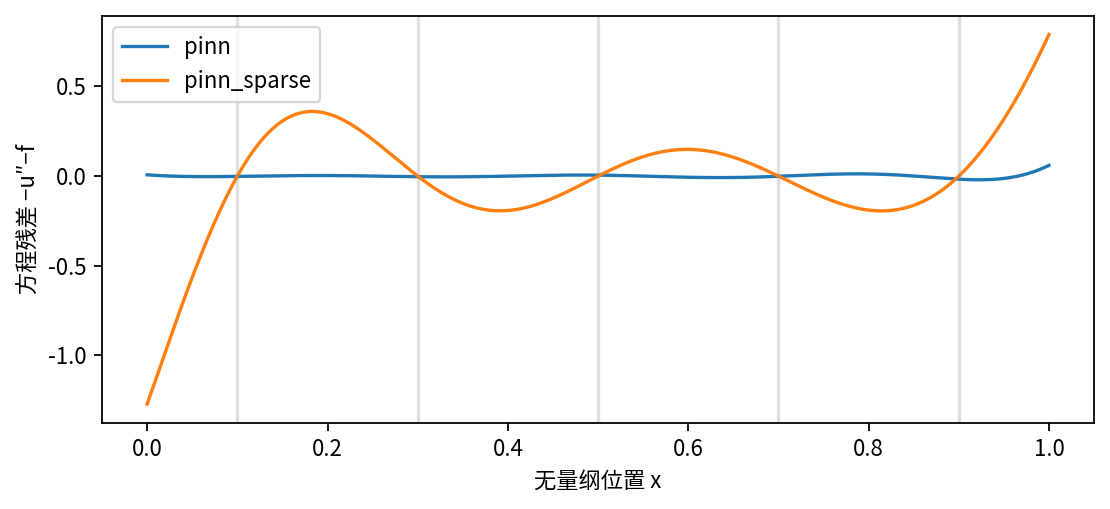

In [7]:
import runpy
runpy.run_path("make_figures.py",run_name="__main__")
from IPython.display import Image,display
display(Image(filename="figures/03_residual.png"))

## 7 最终自检与反思
说明该网络为什么仍然只是固定热源的一个解，不是热源函数到解函数的算子。

In [8]:
result=unittest.TextTestRunner(verbosity=2).run(unittest.defaultTestLoader.loadTestsFromModule(test_experiment))
assert result.wasSuccessful()

test_all_parameter_groups_update (test_experiment.RobustnessTests.test_all_parameter_groups_update) ... 

ok


test_bad_parameter_shapes (test_experiment.RobustnessTests.test_bad_parameter_shapes) ... 

ok


test_fd_zero_boundary_and_balance (test_experiment.RobustnessTests.test_fd_zero_boundary_and_balance) ... 

...

test_input_derivative (test_experiment.Tests.test_input_derivative) ... 

ok


test_saved_results (test_experiment.Tests.test_saved_results) ... 

ok


----------------------------------------------------------------------
Ran 13 tests in 0.019s

OK
